In [161]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import os, cv2, json, random, warnings
warnings.filterwarnings('ignore')

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [162]:
# Cell 2 – Load your own images, resize to a fixed size, build uniform array

DATA_ROOT = '/content/drive/MyDrive/players'

# Only the players you actually downloaded
players = [
    'Lionel Messi',
    'Cristiano Ronaldo',
    'Kylian Mbappe',
    'Erling Haaland',
    'Neymar Jr'
]

target_names = players
num_classes = len(players)
FIXED_SIZE = (256, 256)   # resize all images to this size immediately

def load_and_resize(player_name):
    folder = os.path.join(DATA_ROOT, player_name)
    images = []
    if not os.path.exists(folder):
        print(f"WARNING: Folder not found: {folder}")
        return images
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(folder, fname))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Resize to a fixed size now
                img = cv2.resize(img, FIXED_SIZE)
                images.append(img)
    print(f"{player_name}: {len(images)} images")
    return images

X_raw = []
y_raw = []
for idx, player in enumerate(players):
    for img in load_and_resize(player):
        X_raw.append(img)
        y_raw.append(idx)

X_raw = np.array(X_raw, dtype='uint8')   # now all images have the same shape
y_raw = np.array(y_raw)

print(f"\nTotal images: {X_raw.shape[0]}, Image shape: {X_raw.shape[1:]}, Classes: {num_classes}")

Lionel Messi: 70 images
Cristiano Ronaldo: 41 images
Kylian Mbappe: 33 images
Erling Haaland: 69 images
Neymar Jr: 49 images

Total images: 262, Image shape: (256, 256, 3), Classes: 5


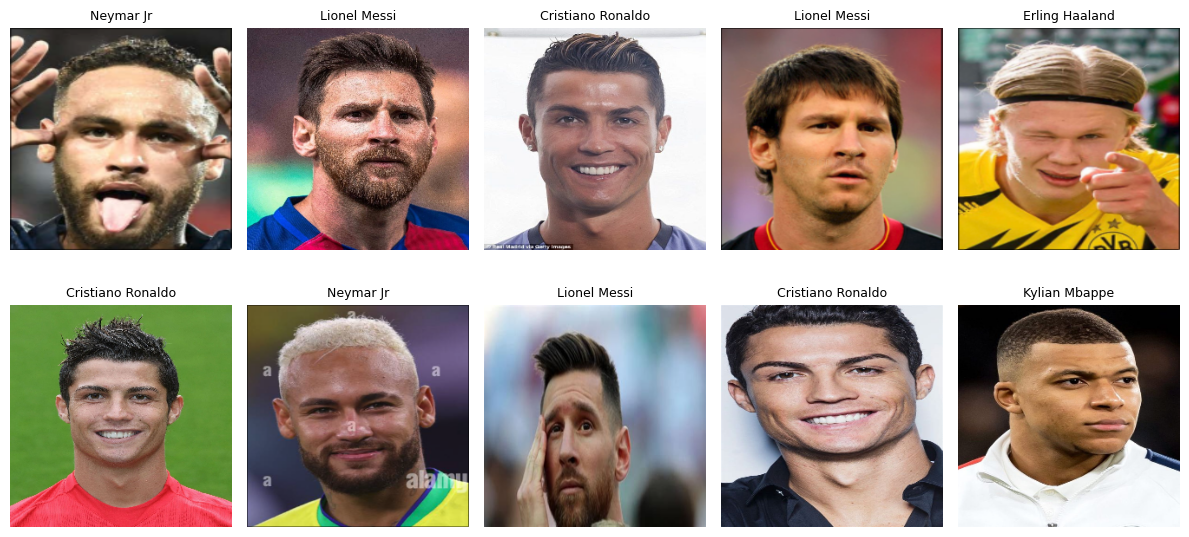

In [165]:
fig, axes = plt.subplots(2, 5, figsize=(12,6))
for i, ax in enumerate(axes.flat):
    if i >= len(X_raw):
        break
    idx = random.randint(0, len(X_raw)-1)
    ax.imshow(X_raw[idx])
    ax.set_title(target_names[y_raw[idx]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [166]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (183, 256, 256, 3), Val: (39, 256, 256, 3), Test: (40, 256, 256, 3)


In [167]:
IMG_SIZE = (128, 128)

def preprocess_images(images):
    # Convert to float32, resize, scale to [0,1]
    imgs = tf.image.resize(images.astype('float32'), IMG_SIZE) / 255.0
    return imgs.numpy()

X_train_proc = preprocess_images(X_train)
X_val_proc   = preprocess_images(X_val)
X_test_proc  = preprocess_images(X_test)

# Flattened for MLP
flat_dim = IMG_SIZE[0] * IMG_SIZE[1] * 3
X_train_flat = X_train_proc.reshape(-1, flat_dim)
X_val_flat   = X_val_proc.reshape(-1, flat_dim)
X_test_flat  = X_test_proc.reshape(-1, flat_dim)

print("Data shapes:")
print(f"Train (CNN): {X_train_proc.shape}")

Data shapes:
Train (CNN): (183, 128, 128, 3)


In [168]:
class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
cw_dict = dict(enumerate(class_weights))
print("Class weights:", cw_dict)

with open('target_names.json', 'w') as f:
    json.dump(target_names, f)

Class weights: {0: np.float64(0.746938775510204), 1: np.float64(1.2620689655172415), 2: np.float64(1.5913043478260869), 3: np.float64(0.7625), 4: np.float64(1.076470588235294)}


In [169]:
def create_mlp():
    model = keras.Sequential([
        layers.Input(shape=(flat_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

mlp = create_mlp()
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=80, batch_size=8,
    callbacks=[early_stop],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.1803 - loss: 54.2094 - val_accuracy: 0.2308 - val_loss: 29.7492
Epoch 2/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2404 - loss: 44.3059 - val_accuracy: 0.3846 - val_loss: 7.9532
Epoch 3/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2623 - loss: 21.8679 - val_accuracy: 0.3333 - val_loss: 2.1525
Epoch 4/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2404 - loss: 10.8844 - val_accuracy: 0.3333 - val_loss: 2.0171
Epoch 5/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2186 - loss: 2.7159 - val_accuracy: 0.2051 - val_loss: 1.6026
Epoch 6/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2295 - loss: 1.7122 - val_accuracy: 0.3077 - val_loss: 1.5220
Epoch 7/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1967 - loss: 1.7251 - val_accuracy: 0.2821 - val_loss: 1.5310
Epoch 8/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1694 - loss: 1.5800 - val_accuracy: 0.17

In [170]:
# Cell 7 – Simpler CNN (with less parameters)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

def create_cnn():
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)     # replaces the large Flatten layer
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

cnn_model = create_cnn()
cnn_model.summary()

Model: "functional_148"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_55 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_19 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [171]:
cnn_adam = keras.models.clone_model(cnn_model)
cnn_adam.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_adam = cnn_adam.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=80, batch_size=8,
    callbacks=[early_stop],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1803 - loss: 2.1612 - val_accuracy: 0.2564 - val_loss: 1.6023
Epoch 2/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2077 - loss: 1.9100 - val_accuracy: 0.2564 - val_loss: 1.5990
Epoch 3/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1803 - loss: 1.9241 - val_accuracy: 0.1538 - val_loss: 1.6283
Epoch 4/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1913 - loss: 1.7836 - val_accuracy: 0.2051 - val_loss: 1.6297
Epoch 5/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2022 - loss: 1.7785 - val_accuracy: 0.1538 - val_loss: 1.6709
Epoch 6/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1913 - loss: 1.6862 - val_accuracy: 0.1282 - val_loss: 1.6970
Epoch 7/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2077 - loss: 1.7248 - val_accuracy: 0.2051 - val_loss: 1.6286
Epoch 8/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2131 - loss: 1.7003 - val_accuracy: 0.2051 - v

In [172]:
cnn_sgd = keras.models.clone_model(cnn_model)
cnn_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist_sgd = cnn_sgd.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=80, batch_size=8,
    callbacks=[early_stop],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.1421 - loss: 1.9423 - val_accuracy: 0.2051 - val_loss: 1.6093
Epoch 2/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2022 - loss: 1.8381 - val_accuracy: 0.1282 - val_loss: 1.6119
Epoch 3/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1749 - loss: 1.7692 - val_accuracy: 0.1282 - val_loss: 1.6143
Epoch 4/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1749 - loss: 1.7626 - val_accuracy: 0.2564 - val_loss: 1.6167
Epoch 5/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1639 - loss: 1.7739 - val_accuracy: 0.2564 - val_loss: 1.6146
Epoch 6/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1858 - loss: 1.7878 - val_accuracy: 0.2564 - val_loss: 1.6067
Epoch 7/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1913 - loss: 1.7625 - val_accuracy: 0.2564 - val_loss: 1.6120
Epoch 8/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1858 - loss: 1.7513 - val_accuracy: 0.1282 - v

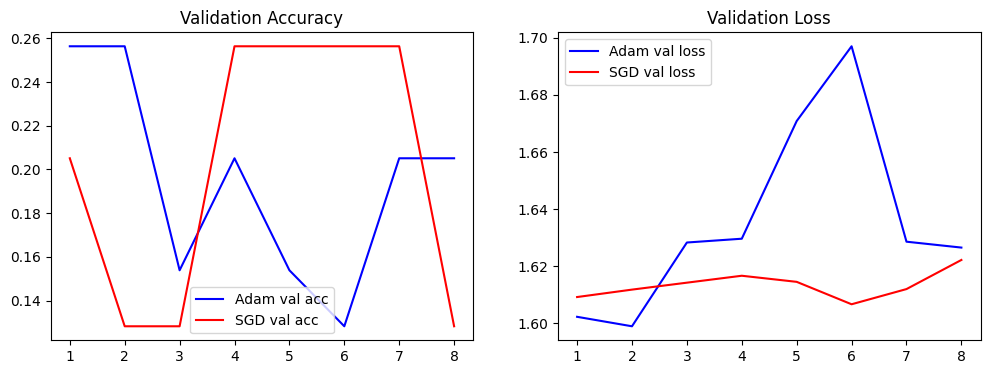

In [173]:
def plot_optim_comp(h1, h2, l1='Adam', l2='SGD'):
    e1 = range(1, len(h1.history['val_accuracy'])+1)
    e2 = range(1, len(h2.history['val_accuracy'])+1)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    ax1.plot(e1, h1.history['val_accuracy'], 'b-', label=f'{l1} val acc')
    ax1.plot(e2, h2.history['val_accuracy'], 'r-', label=f'{l2} val acc')
    ax1.set_title('Validation Accuracy')
    ax1.legend()
    ax2.plot(e1, h1.history['val_loss'], 'b-', label=f'{l1} val loss')
    ax2.plot(e2, h2.history['val_loss'], 'r-', label=f'{l2} val loss')
    ax2.set_title('Validation Loss')
    ax2.legend()
    plt.show()

plot_optim_comp(hist_adam, hist_sgd)

In [174]:
# Resize and preprocess for ResNet50
def preprocess_resnet(images):
    x = tf.image.resize(images.astype('float32'), (224, 224))
    x = tf.keras.applications.resnet50.preprocess_input(x)
    return x.numpy()

X_train_resnet = preprocess_resnet(X_train)
X_val_resnet   = preprocess_resnet(X_val)
X_test_resnet  = preprocess_resnet(X_test)

base_model = keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
resnet_model = keras.Model(inputs, outputs)

resnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_resnet = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

hist_resnet = resnet_model.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=50, batch_size=4,
    callbacks=[early_stop_resnet, reduce_lr],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.3388 - loss: 2.2601 - val_accuracy: 0.5641 - val_loss: 0.9339 - learning_rate: 0.0010
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5137 - loss: 1.4137 - val_accuracy: 0.6923 - val_loss: 0.8849 - learning_rate: 0.0010
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5683 - loss: 1.0928 - val_accuracy: 0.8718 - val_loss: 0.5739 - learning_rate: 0.0010
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7158 - loss: 0.8104 - val_accuracy: 0.8974 - val_loss: 0.4840 - learning_rate: 0.0010
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7104 - loss: 0.8593 - val_accuracy: 0.8974 - val_loss: 0.4926 - learning_rate: 0.0010
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7869 - loss: 0.5982 - val_accuracy: 0.8974 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7760 - loss: 0.5612 - val_a

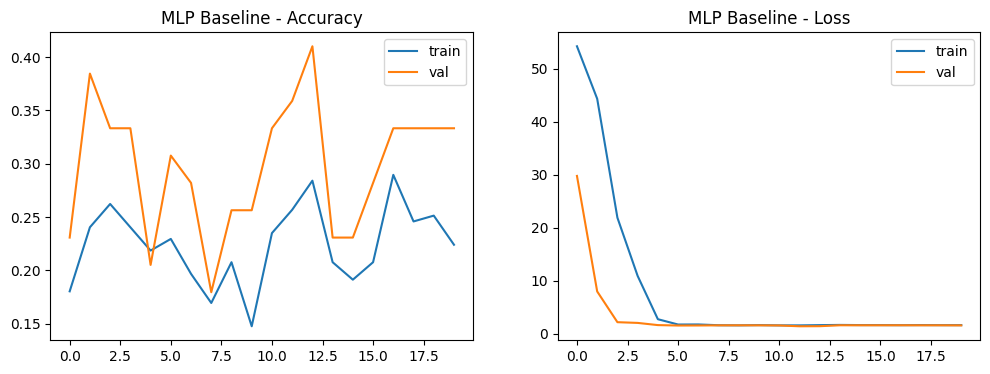

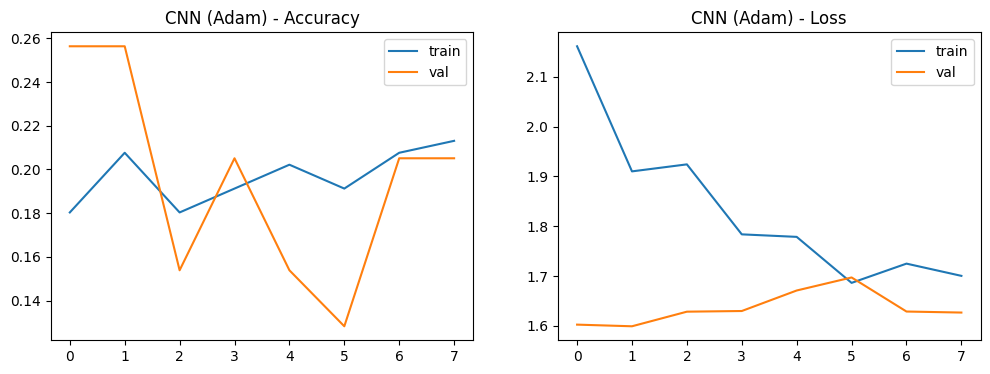

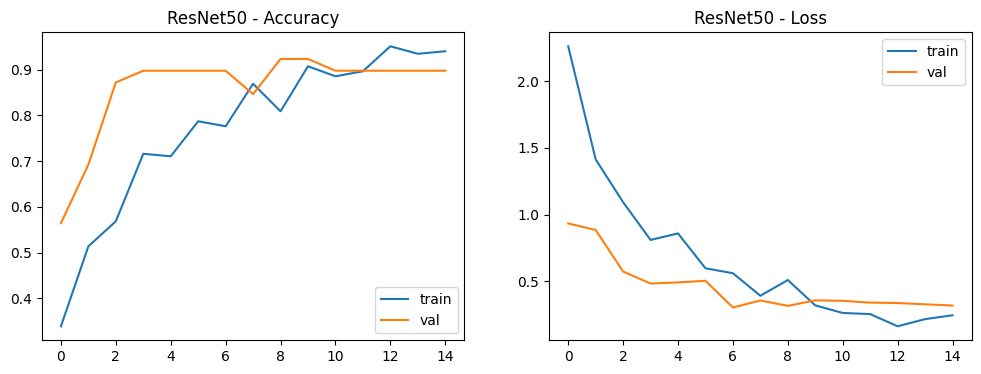


ResNet50 Test accuracy: 0.7500
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step


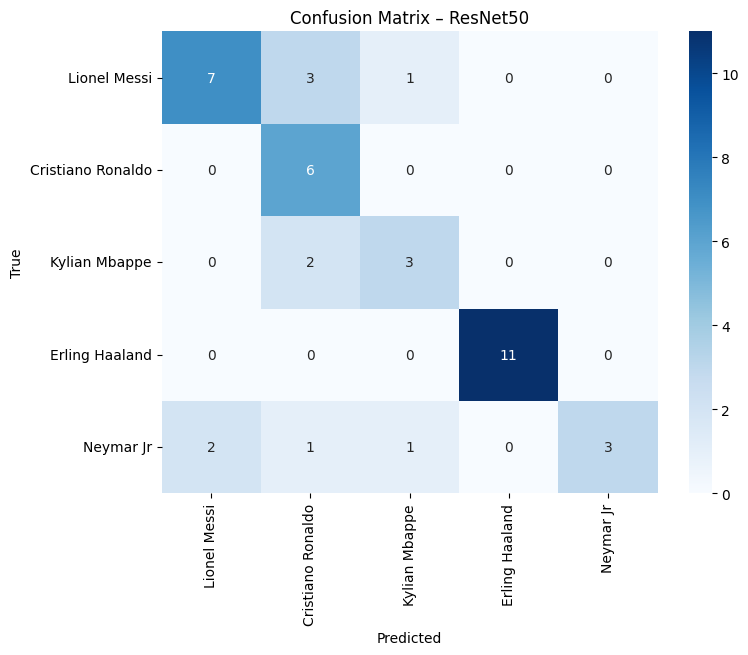


Classification Report:
                   precision    recall  f1-score   support

     Lionel Messi       0.78      0.64      0.70        11
Cristiano Ronaldo       0.50      1.00      0.67         6
    Kylian Mbappe       0.60      0.60      0.60         5
   Erling Haaland       1.00      1.00      1.00        11
        Neymar Jr       1.00      0.43      0.60         7

         accuracy                           0.75        40
        macro avg       0.78      0.73      0.71        40
     weighted avg       0.81      0.75      0.75        40



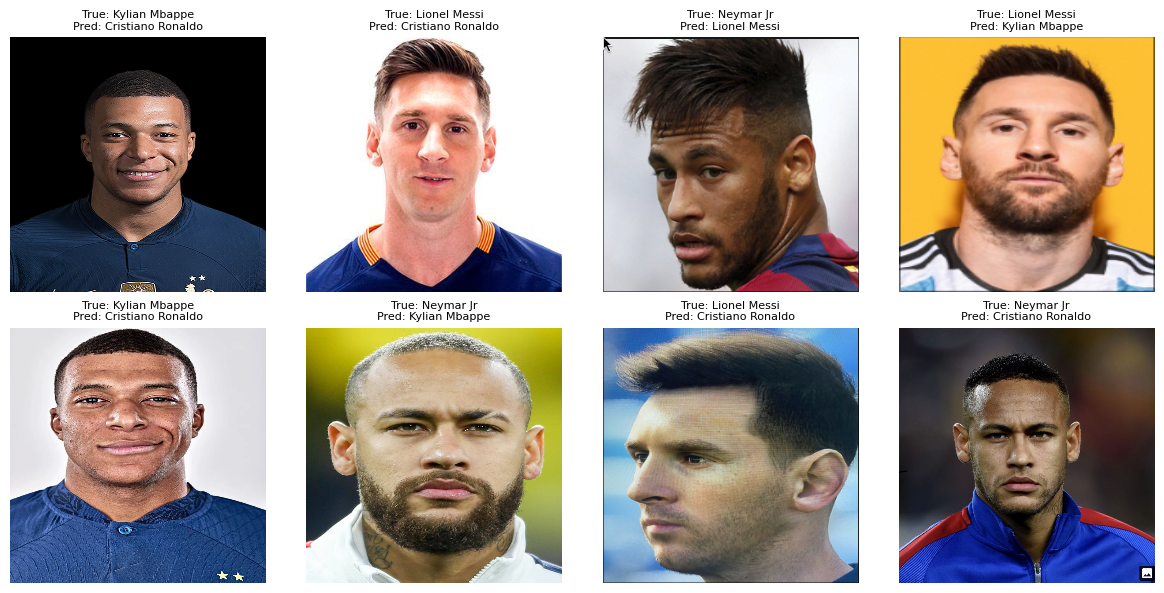

In [175]:
# Learning curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.show()

plot_history(history_mlp, 'MLP Baseline')
plot_history(hist_adam, 'CNN (Adam)')
plot_history(hist_resnet, 'ResNet50')

# Test set evaluation (using best model: ResNet50)
test_loss, test_acc = resnet_model.evaluate(X_test_resnet, y_test, verbose=0)
print(f"\nResNet50 Test accuracy: {test_acc:.4f}")

y_pred_probs = resnet_model.predict(X_test_resnet)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.title('Confusion Matrix – ResNet50')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Show a few misclassified examples (if any)
mis = np.where(y_pred != y_test)[0]
if len(mis) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(12,6))
    for i, idx in enumerate(mis[:8]):
        ax = axes[i//4, i%4]
        ax.imshow(X_test[idx])
        ax.set_title(f"True: {target_names[y_test[idx]]}\nPred: {target_names[y_pred[idx]]}", fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [176]:
resnet_model.save('model.keras')
print("Model saved as model.keras")

Model saved as model.keras


In [177]:
# Cell 11 – Advanced Model: MobileNetV2 (a lighter, more efficient choice)
def preprocess_mobilenet(images):
    x = tf.image.resize(images.astype('float32'), (224, 224))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x.numpy()

X_train_mnet = preprocess_mobilenet(X_train)
X_val_mnet   = preprocess_mobilenet(X_val)
X_test_mnet  = preprocess_mobilenet(X_test)

base_model = keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
mnet_model = keras.Model(inputs, outputs)

mnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_mnet = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)

hist_mnet = mnet_model.fit(
    X_train_mnet, y_train,
    validation_data=(X_val_mnet, y_val),
    epochs=50, batch_size=8,
    callbacks=[early_stop_mnet, reduce_lr],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 644ms/step - accuracy: 0.3388 - loss: 2.0795 - val_accuracy: 0.3846 - val_loss: 1.3482 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4426 - loss: 1.4474 - val_accuracy: 0.6923 - val_loss: 0.9173 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5574 - loss: 1.1321 - val_accuracy: 0.8718 - val_loss: 0.7762 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6066 - loss: 1.0341 - val_accuracy: 0.8718 - val_loss: 0.6260 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6885 - loss: 0.8293 - val_accuracy: 0.8718 - val_loss: 0.5162 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7432 - loss: 0.7097 - val_accuracy: 0.8205 - val_loss: 0.4929 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7760 - loss: 0.6517 - val_a

In [ ]:
%%writefile app.py
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow import keras
from PIL import Image

# Load the Keras model
model = keras.models.load_model('model.keras')

CLASS_NAMES = [
    'Lionel Messi',
    'Cristiano Ronaldo',
    'Kylian Mbappe',
    'Erling Haaland',
    'Neymar Jr'
]

def predict(image):
    # Preprocess exactly as during training for ResNet50
    img = image.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    # ResNet50 preprocessing: BGR + mean subtraction
    mean = np.array([103.939, 116.779, 123.68])
    img_bgr = img_array[..., ::-1]          # RGB -> BGR
    img_bgr -= mean
    input_data = np.expand_dims(img_bgr, axis=0)

    output = model.predict(input_data, verbose=0)
    pred_idx = int(np.argmax(output[0]))
    confidence = float(np.max(output[0]))
    return {CLASS_NAMES[i]: float(output[0][i]) for i in range(len(CLASS_NAMES))}

iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label="Upload a player's photo"),
    outputs=gr.Label(num_top_classes=4),
    title="⚽ Football Player Face Recognition",
    description="Upload a photo of Messi, Ronaldo, Mbappé or Neymar."
)

iface.launch(server_name="0.0.0.0", server_port=7860)

In [ ]:
%%writefile requirements.txt
tensorflow==2.19.0
gradio==6.0.0
pillow
numpy

In [ ]:
%%writefile Dockerfile
FROM python:3.11-slim

WORKDIR /app

RUN apt-get update && apt-get install -y git && rm -rf /var/lib/apt/lists/*

COPY requirements.txt requirements.txt
RUN pip install --upgrade pip && pip install -r requirements.txt

COPY . .

CMD ["python", "app.py"]

In [ ]:
!pip install huggingface_hub -q

import os
from google.colab import userdata
from huggingface_hub import HfApi, login

# Retrieve secrets from Colab's secret manager
hf_token = userdata.get('HUGGING_FACE')

username = userdata.get('USERNAME')
space_name = userdata.get('SPACE_NAME')

# Login using the retrieved token
login(token=hf_token)

api = HfApi()
repo_id = f"{username}/{space_name}"

# Upload the files
files_to_upload = ["model.keras", "app.py", "requirements.txt", "Dockerfile"]

for file in files_to_upload:
    print(f"Uploading {file}...")
    api.upload_file(
        path_or_fileobj=file,
        path_in_repo=file,
        repo_id=repo_id,
        repo_type="space"
    )


print("Files uploaded. Your Space will automatically build and deploy.")